# SOEC + HB ammonia NPV simulation

Run the Monte Carlo ammonia NPV model for SOEC + HB at 1,000,000 tNH3/year. The notebook shows NPV, LPM, and LCOA distributions, NPV sign counts, and mean annual cost components.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ammonia.ammonia_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_ammonia_results,
)
from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution

pd.options.display.float_format = "{:,.3f}".format

In [2]:
TECHNOLOGY = "soec_hb"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

simulation = simulate_ammonia_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()

,run_id,technology,technology_type,retrofit_bau_mode,annual_output_tnh3,lifetime_years,capex_eur_per_tnh3,fixed_opex_eur_per_tnh3,variable_opex_eur_per_tnh3,fuel_type,...,annual_electricity_cost_eur,annual_transport_and_storage_cost_eur,annual_emissions_cost_eur,annual_total_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_tnh3,present_value_total_cost_eur,lcoa_eur_per_tnh3,levelized_profit_margin_eur_per_tnh3
0,0,soec_hb,absolute,not_applicable,"1,000,000.000",25,"3,404.648",201.857,21.534,none,...,"911,652,934.738",0.000,0.000,"1,135,044,125.117","-245,044,125.117","-6,020,439,638.487","10,674,776.189","15,520,990,446.330","1,453.987",-563.987
1,1,soec_hb,absolute,not_applicable,"1,000,000.000",25,"2,347.977",184.260,18.982,none,...,"1,001,638,751.090",0.000,0.000,"1,204,881,642.468","-314,881,642.468","-5,709,268,237.926","10,674,776.189","15,209,819,045.769","1,424.837",-534.837
2,2,soec_hb,absolute,not_applicable,"1,000,000.000",25,"2,142.430",159.765,19.246,none,...,"749,593,109.455",0.000,0.000,"928,603,451.027","-38,603,451.027","-2,554,513,292.221","10,674,776.189","12,055,064,100.065","1,129.304",-239.304
3,3,soec_hb,absolute,not_applicable,"1,000,000.000",25,"3,147.972",158.106,20.057,none,...,"997,388,675.617",0.000,0.000,"1,175,551,157.616","-285,551,157.616","-6,196,167,078.123","10,674,776.189","15,696,717,885.967","1,470.449",-580.449
4,4,soec_hb,absolute,not_applicable,"1,000,000.000",25,"2,931.184",185.878,19.426,none,...,"1,066,301,280.415",0.000,0.000,"1,271,605,942.254","-381,605,942.254","-7,004,742,414.624","10,674,776.189","16,505,293,222.468","1,546.196",-656.196


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcoa_eur_per_tnh3 = results["lcoa_eur_per_tnh3"]
levelized_profit_margin_eur_per_tnh3 = results["levelized_profit_margin_eur_per_tnh3"]

summary = pd.concat([
    npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename("NPV million EUR"),
    levelized_profit_margin_eur_per_tnh3.describe(percentiles=[0.05, 0.5, 0.95]).rename("LPM EUR/tNH3"),
    lcoa_eur_per_tnh3.describe(percentiles=[0.05, 0.5, 0.95]).rename("LCOA EUR/tNH3"),
], axis=1)
npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame([
    {"NPV category": "Non-negative (NPV >= 0)", "Count": npv_signs["non_negative_count"], "Share": npv_signs["non_negative_share"]},
    {"NPV category": "Negative (NPV < 0)", "Count": npv_signs["negative_count"], "Share": 1 - npv_signs["non_negative_share"]},
])
display(summary, npv_sign_summary)

,NPV million EUR,LPM EUR/tNH3,LCOA EUR/tNH3
count,"100,000.000","100,000.000","100,000.000"
mean,"-5,195.159",-486.676,"1,376.676"
std,"2,167.657",203.063,203.063
min,"-11,460.018","-1,073.560",835.686
5%,"-8,729.760",-817.793,"1,046.861"
50%,"-5,192.208",-486.400,"1,376.400"
95%,"-1,674.452",-156.861,"1,707.793"
max,579.785,54.314,"1,963.560"


,NPV category,Count,Share
0,Non-negative (NPV >= 0),57,0.001
1,Negative (NPV < 0),99943,0.999


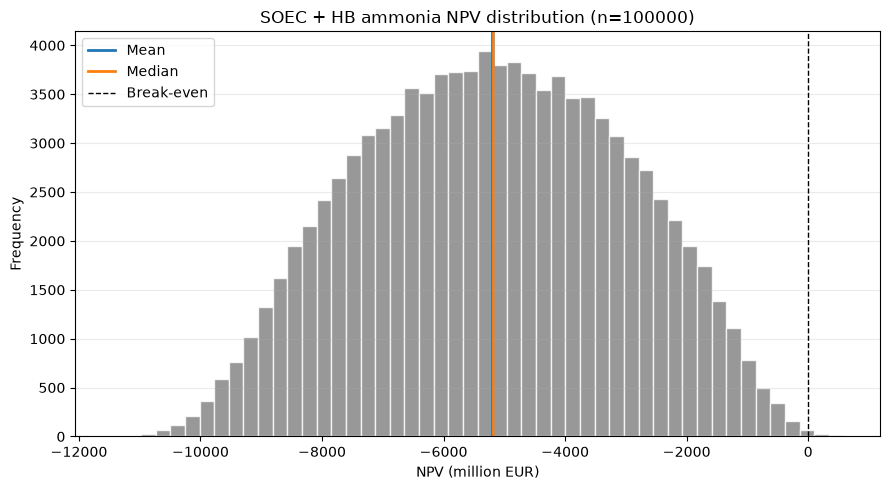

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"SOEC + HB ammonia NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()

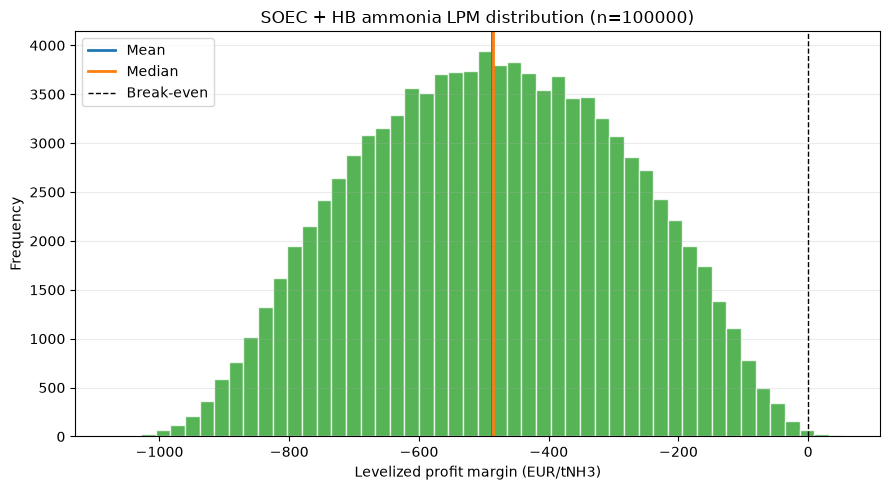

In [5]:
plot_financial_metric_distribution(
    levelized_profit_margin_eur_per_tnh3,
    title=f"SOEC + HB ammonia LPM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized profit margin (EUR/tNH3)",
    color="tab:green",
    show_break_even=True,
)
plt.show()

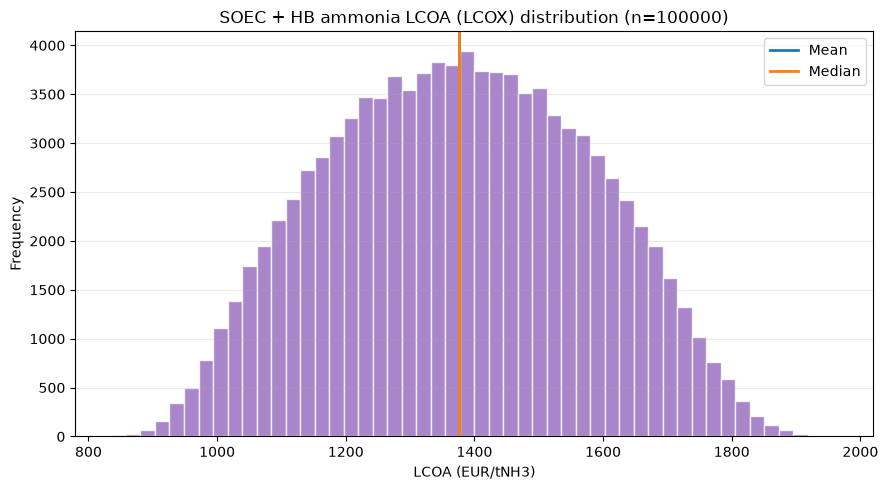

In [6]:
plot_financial_metric_distribution(
    lcoa_eur_per_tnh3,
    title=f"SOEC + HB ammonia LCOA (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOA (EUR/tNH3)",
    color="tab:purple",
)
plt.show()

In [7]:
annual_columns = [
    "annual_revenue_eur",
    "annual_fixed_opex_eur",
    "annual_variable_opex_eur",
    "annual_natural_gas_cost_eur",
    "annual_coal_cost_eur",
    "annual_biomass_cost_eur",
    "annual_fuel_cost_eur",
    "annual_electricity_cost_eur",
    "annual_transport_and_storage_cost_eur",
    "annual_emissions_cost_eur",
    "annual_net_cash_flow_eur",
]
(results[annual_columns] / 1_000_000).mean().rename("Mean annual value, million EUR")

annual_revenue_eur                       890.000
annual_fixed_opex_eur                    181.539
annual_variable_opex_eur                  20.066
annual_natural_gas_cost_eur                0.000
annual_coal_cost_eur                       0.000
annual_biomass_cost_eur                    0.000
annual_fuel_cost_eur                       0.000
annual_electricity_cost_eur              925.036
annual_transport_and_storage_cost_eur      0.000
annual_emissions_cost_eur                  0.000
annual_net_cash_flow_eur                -236.641
Name: Mean annual value, million EUR, dtype: float64